In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import pickle
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)
from sklearn.model_selection import cross_val_score
import xgboost as xgb

import mlflow
import mlflow.sklearn
import mlflow.xgboost

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

In [2]:

X_train = np.load('../data/processed/X_train.npy')
X_test = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

with open('../models/feature_names.pkl', 'rb') as f:
    feature_names = pickle.load(f)

with open('../models/preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

print(f"Data loaded successfully")
print(f"Training set: {X_train.shape}")
print(f"Test set: {X_test.shape}")
print(f"Features: {len(feature_names)}")
print(f"Class distribution - Train: {np.bincount(y_train.astype(int))}")
print(f"Class distribution - Test: {np.bincount(y_test.astype(int))}")

scale_pos_weight = np.sum(y_train == 0) / np.sum(y_train == 1)
print(f"Scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

Data loaded successfully
Training set: (5634, 48)
Test set: (1409, 48)
Features: 48
Class distribution - Train: [4139 1495]
Class distribution - Test: [1035  374]
Scale_pos_weight for XGBoost: 2.77


In [3]:
mlflow.set_experiment("churn-prediction")

print("MLflow experiment set: churn-prediction")
print(f"Tracking URI: {mlflow.get_tracking_uri()}")
print(f"Artifact location: {mlflow.get_artifact_uri()}")

2026/04/12 20:33:47 INFO mlflow.tracking.fluent: Experiment with name 'churn-prediction' does not exist. Creating a new experiment.


MLflow experiment set: churn-prediction
Tracking URI: file:///c:/Users/chiru/OneDrive/Desktop/customer-churn-prediction-mlops/notebooks/mlruns
Artifact location: file:///c:/Users/chiru/OneDrive/Desktop/customer-churn-prediction-mlops/notebooks/mlruns/743988450244179340/5da3dc5e706e4458942d0542aadff841/artifacts


In [4]:
def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    """
    Comprehensive model evaluation with all relevant metrics.
    """
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    y_train_proba = model.predict_proba(X_train)[:, 1]
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'train_accuracy': accuracy_score(y_train, y_train_pred),
        'test_accuracy': accuracy_score(y_test, y_test_pred),
        'train_precision': precision_score(y_train, y_train_pred),
        'test_precision': precision_score(y_test, y_test_pred),
        'train_recall': recall_score(y_train, y_train_pred),
        'test_recall': recall_score(y_test, y_test_pred),
        'train_f1': f1_score(y_train, y_train_pred),
        'test_f1': f1_score(y_test, y_test_pred),
        'train_roc_auc': roc_auc_score(y_train, y_train_proba),
        'test_roc_auc': roc_auc_score(y_test, y_test_proba),
        'train_pr_auc': average_precision_score(y_train, y_train_proba),
        'test_pr_auc': average_precision_score(y_test, y_test_proba)
    }
    
    print(f"\n{model_name} Performance:")
    print(f"{'Metric':<20} {'Train':>12} {'Test':>12} {'Difference':>12}")

    
    for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']:
        train_val = metrics[f'train_{metric}']
        test_val = metrics[f'test_{metric}']
        diff = train_val - test_val
        print(f"{metric:<20} {train_val:>12.4f} {test_val:>12.4f} {diff:>12.4f}")
    
    cm = confusion_matrix(y_test, y_test_pred)
    print(f"\nConfusion Matrix (Test Set):")
    print(f"              Predicted")
    print(f"              No    Yes")
    print(f"Actual No   {cm[0,0]:5d} {cm[0,1]:5d}")
    print(f"       Yes  {cm[1,0]:5d} {cm[1,1]:5d}")
    
    return metrics, cm

def plot_confusion_matrix(cm, model_name, save_path=None):
    """
    Plot confusion matrix heatmap.
    """
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=['No Churn', 'Churn'],
                yticklabels=['No Churn', 'Churn'],
                ax=ax, cbar_kws={'label': 'Count'})
    
    ax.set_xlabel('Predicted Label', fontsize=12, fontweight='bold')
    ax.set_ylabel('True Label', fontsize=12, fontweight='bold')
    ax.set_title(f'Confusion Matrix - {model_name}', fontsize=14, fontweight='bold')
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fig

def plot_roc_pr_curves(y_test, y_proba, model_name, save_path=None):
    """
    Plot ROC and Precision-Recall curves.
    """
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = roc_auc_score(y_test, y_proba)
    
    precision, recall, _ = precision_recall_curve(y_test, y_proba)
    pr_auc = average_precision_score(y_test, y_proba)
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    ax1.plot(fpr, tpr, color='darkorange', lw=2, 
             label=f'ROC curve (AUC = {roc_auc:.3f})')
    ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
    ax1.set_xlim([0.0, 1.0])
    ax1.set_ylim([0.0, 1.05])
    ax1.set_xlabel('False Positive Rate', fontweight='bold')
    ax1.set_ylabel('True Positive Rate', fontweight='bold')
    ax1.set_title(f'ROC Curve - {model_name}', fontweight='bold')
    ax1.legend(loc="lower right")
    ax1.grid(alpha=0.3)
    
    ax2.plot(recall, precision, color='darkorange', lw=2,
             label=f'PR curve (AUC = {pr_auc:.3f})')
    ax2.axhline(y=np.mean(y_test), color='navy', linestyle='--', lw=2, label='Baseline')
    ax2.set_xlim([0.0, 1.0])
    ax2.set_ylim([0.0, 1.05])
    ax2.set_xlabel('Recall', fontweight='bold')
    ax2.set_ylabel('Precision', fontweight='bold')
    ax2.set_title(f'Precision-Recall Curve - {model_name}', fontweight='bold')
    ax2.legend(loc="lower left")
    ax2.grid(alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fig

print("Evaluation functions defined")

Evaluation functions defined


In [6]:
mlflow.end_run()
print("Any active MLflow runs have been ended")

Any active MLflow runs have been ended


Training Baseline Model: Logistic Regression

Logistic Regression (Baseline) Performance:
Metric                      Train         Test   Difference
accuracy                   0.7543       0.7438       0.0106
precision                  0.5243       0.5111       0.0132
recall                     0.8007       0.7995       0.0012
f1                         0.6337       0.6236       0.0101
roc_auc                    0.8516       0.8436       0.0079
pr_auc                     0.6718       0.6422       0.0296

Confusion Matrix (Test Set):
              Predicted
              No    Yes
Actual No     749   286
       Yes     75   299


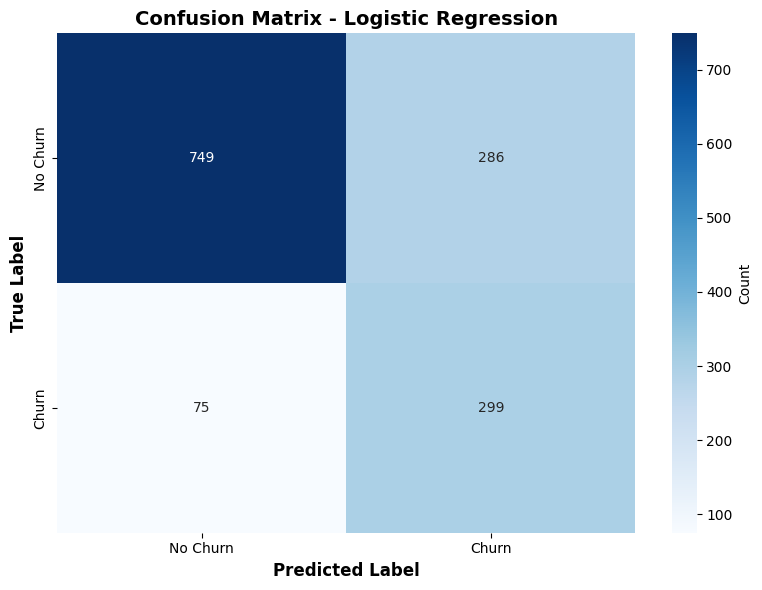

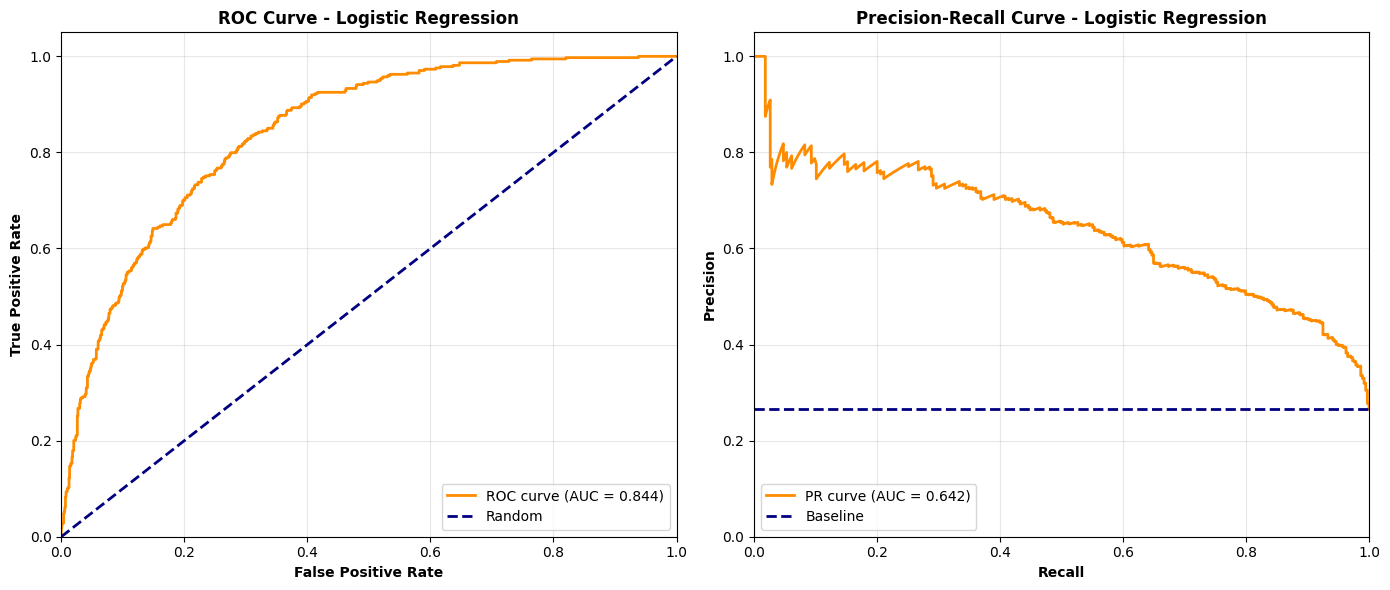


MLflow Run ID: d4b98a3513d5470b8200b7b6fd68724d
Model saved to: ../models/baseline_model.pkl

Baseline model training complete


In [7]:
print("Training Baseline Model: Logistic Regression")

with mlflow.start_run(run_name="baseline_logistic_regression"):
    
    params = {
        'penalty': 'l2',
        'C': 1.0,
        'solver': 'lbfgs',
        'max_iter': 1000,
        'random_state': RANDOM_STATE,
        'class_weight': 'balanced'
    }
    
    mlflow.log_params(params)
    
    baseline_model = LogisticRegression(**params)
    baseline_model.fit(X_train, y_train)
    
    metrics, cm = evaluate_model(
        baseline_model, X_train, y_train, X_test, y_test,
        model_name="Logistic Regression (Baseline)"
    )
    
    mlflow.log_metrics(metrics)
    
    y_test_proba = baseline_model.predict_proba(X_test)[:, 1]
    
    cm_fig = plot_confusion_matrix(cm, "Logistic Regression", 
                                    save_path="../models/baseline_confusion_matrix.png")
    mlflow.log_figure(cm_fig, "confusion_matrix.png")
    plt.close(cm_fig)
    
    curves_fig = plot_roc_pr_curves(y_test, y_test_proba, "Logistic Regression",
                                     save_path="../models/baseline_roc_pr_curves.png")
    mlflow.log_figure(curves_fig, "roc_pr_curves.png")
    plt.close(curves_fig)
    
    mlflow.sklearn.log_model(baseline_model, "model")
    
    with open('../models/baseline_model.pkl', 'wb') as f:
        pickle.dump(baseline_model, f)
    
    mlflow.log_artifact('../models/baseline_model.pkl')
    
    run_id = mlflow.active_run().info.run_id
    print(f"\nMLflow Run ID: {run_id}")
    print(f"Model saved to: ../models/baseline_model.pkl")

print("\nBaseline model training complete")

Training XGBoost Model with Class Weights

XGBoost (Class Weighted) Performance:
Metric                      Train         Test   Difference
accuracy                   0.8633       0.7566       0.1068
precision                  0.6725       0.5300       0.1426
recall                     0.9452       0.7326       0.2125
f1                         0.7859       0.6150       0.1708
roc_auc                    0.9527       0.8390       0.1137
pr_auc                     0.8650       0.6509       0.2141

Confusion Matrix (Test Set):
              Predicted
              No    Yes
Actual No     792   243
       Yes    100   274


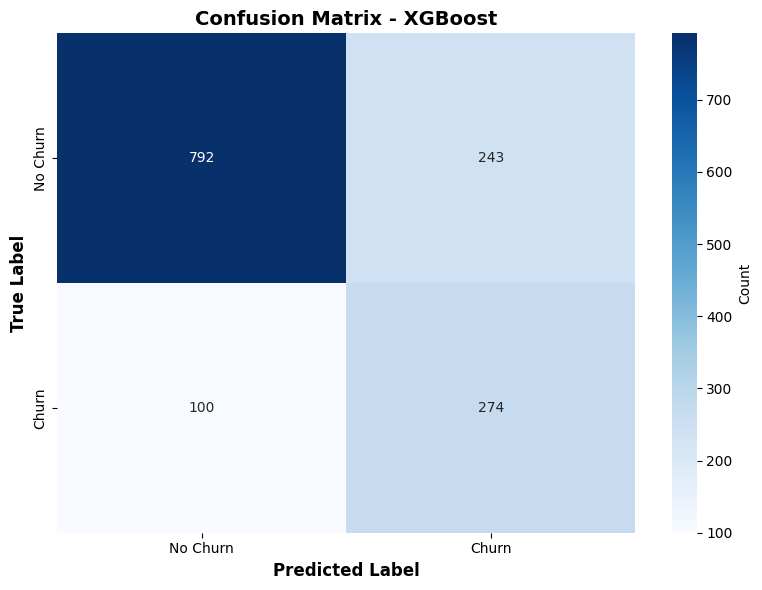

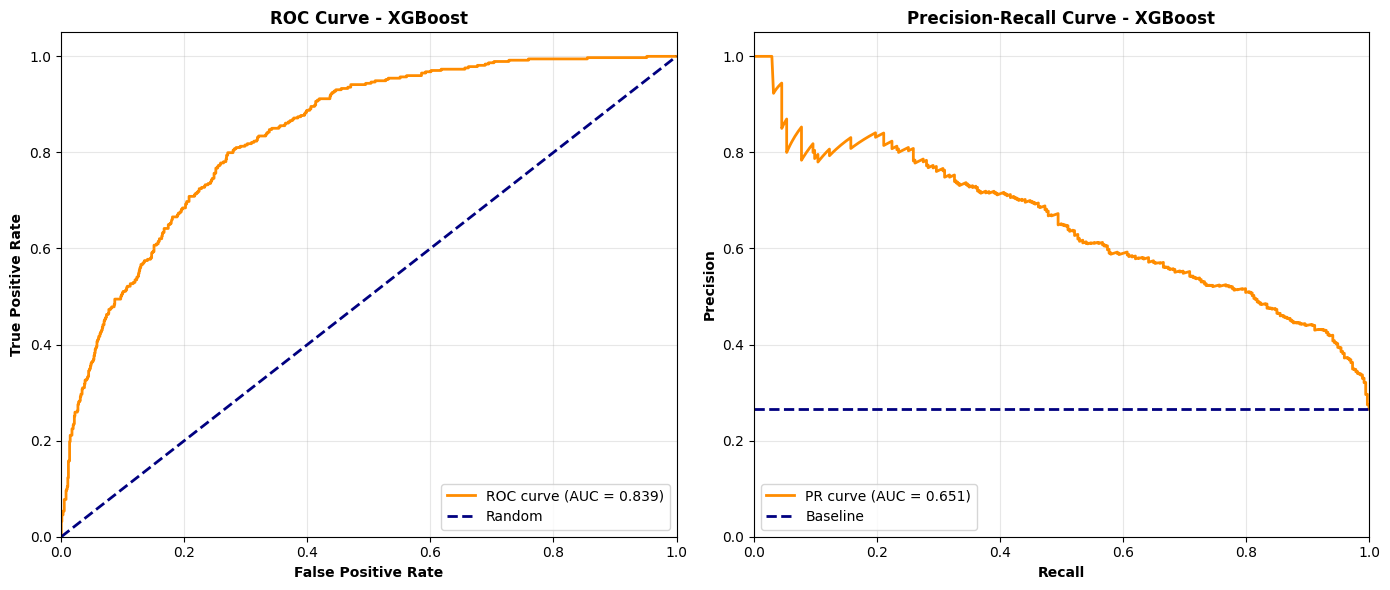


MLflow Run ID: bb10e5c4fb5f45219b409225e98d6ebe
Model saved to: ../models/xgboost_model.pkl

XGBoost model training complete


In [8]:
print("Training XGBoost Model with Class Weights")
with mlflow.start_run(run_name="xgboost_class_weighted"):
    
    params = {
        'n_estimators': 100,
        'max_depth': 6,
        'learning_rate': 0.1,
        'subsample': 0.8,
        'colsample_bytree': 0.8,
        'scale_pos_weight': scale_pos_weight,
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    
    mlflow.log_params(params)
    
    xgb_model = xgb.XGBClassifier(**params)
    
    xgb_model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False
    )
    
    metrics, cm = evaluate_model(
        xgb_model, X_train, y_train, X_test, y_test,
        model_name="XGBoost (Class Weighted)"
    )
    
    mlflow.log_metrics(metrics)
    
    y_test_proba = xgb_model.predict_proba(X_test)[:, 1]
    
    cm_fig = plot_confusion_matrix(cm, "XGBoost", 
                                    save_path="../models/xgboost_confusion_matrix.png")
    mlflow.log_figure(cm_fig, "confusion_matrix.png")
    plt.close(cm_fig)
    
    curves_fig = plot_roc_pr_curves(y_test, y_test_proba, "XGBoost",
                                     save_path="../models/xgboost_roc_pr_curves.png")
    mlflow.log_figure(curves_fig, "roc_pr_curves.png")
    plt.close(curves_fig)
    
    mlflow.xgboost.log_model(xgb_model, "model")
    
    with open('../models/xgboost_model.pkl', 'wb') as f:
        pickle.dump(xgb_model, f)
    
    mlflow.log_artifact('../models/xgboost_model.pkl')
    
    run_id = mlflow.active_run().info.run_id
    print(f"\nMLflow Run ID: {run_id}")
    print(f"Model saved to: ../models/xgboost_model.pkl")

print("\nXGBoost model training complete")

Analyzing Feature Importance
----------------------------------------------------------------------

Top 15 Most Important Features:
                           feature  importance
               is_monthly_contract    0.314310
       InternetService_Fiber optic    0.115002
  OnlineBackup_No internet service    0.085080
                 Contract_Two year    0.067254
       tenure_contract_interaction    0.057829
OnlineSecurity_No internet service    0.054073
                 Contract_One year    0.034292
                InternetService_No    0.023367
               StreamingMovies_Yes    0.017480
    PaymentMethod_Electronic check    0.013267
                     risky_payment    0.013168
                            tenure    0.009978
                      TotalCharges    0.009770
                  PhoneService_Yes    0.009606
                   StreamingTV_Yes    0.009432


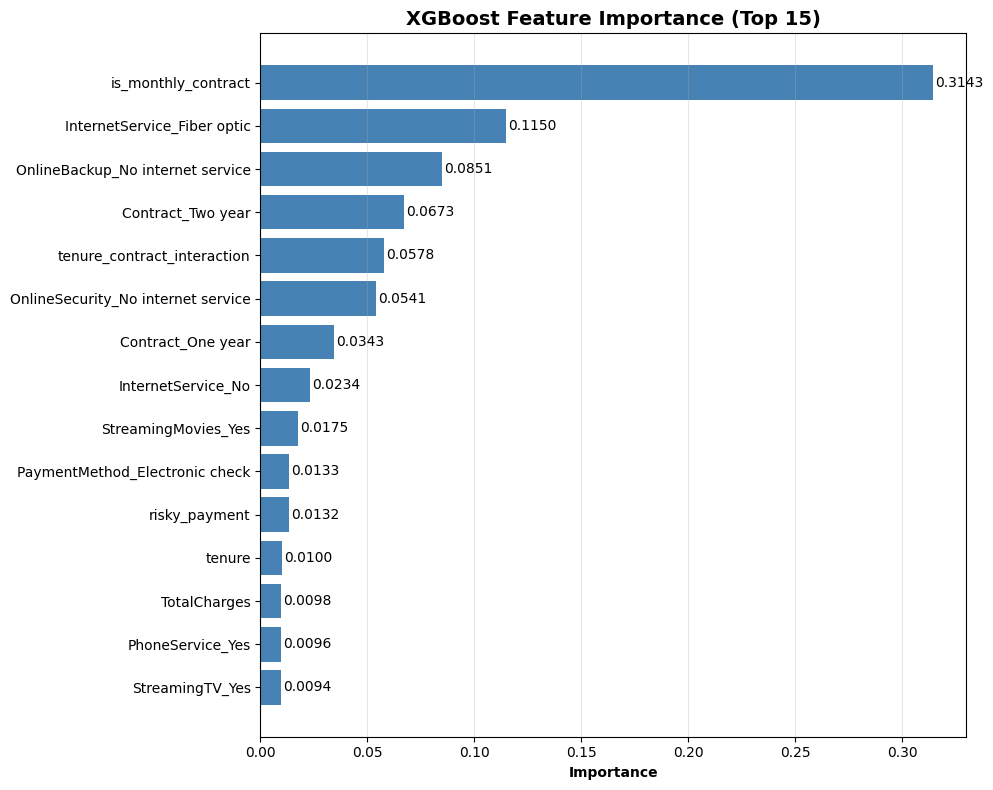


Feature importance saved to: ../models/feature_importance.csv


In [9]:
print("Analyzing Feature Importance")
print("-" * 70)

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("\nTop 15 Most Important Features:")
print(importance_df.head(15).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 8))
top_features = importance_df.head(15).sort_values('importance')
ax.barh(range(len(top_features)), top_features['importance'], color='steelblue')
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'])
ax.set_xlabel('Importance', fontweight='bold')
ax.set_title('XGBoost Feature Importance (Top 15)', fontweight='bold', fontsize=14)
ax.grid(axis='x', alpha=0.3)

for i, v in enumerate(top_features['importance']):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center')

plt.tight_layout()
plt.savefig('../models/xgboost_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

importance_df.to_csv('../models/feature_importance.csv', index=False)
print("\nFeature importance saved to: ../models/feature_importance.csv")

In [12]:
print("Computing final metrics for summary...")

with open('../models/baseline_model.pkl', 'rb') as f:
    baseline_model = pickle.load(f)

with open('../models/xgboost_model.pkl', 'rb') as f:
    xgb_model = pickle.load(f)

y_baseline_pred = baseline_model.predict(X_test)
y_baseline_proba = baseline_model.predict_proba(X_test)[:, 1]

y_xgb_pred = xgb_model.predict(X_test)
y_xgb_proba = xgb_model.predict_proba(X_test)[:, 1]

baseline_metrics = {
    'test_accuracy': float(accuracy_score(y_test, y_baseline_pred)),
    'test_precision': float(precision_score(y_test, y_baseline_pred)),
    'test_recall': float(recall_score(y_test, y_baseline_pred)),
    'test_f1': float(f1_score(y_test, y_baseline_pred)),
    'test_roc_auc': float(roc_auc_score(y_test, y_baseline_proba)),
    'test_pr_auc': float(average_precision_score(y_test, y_baseline_proba))
}

xgb_metrics = {
    'test_accuracy': float(accuracy_score(y_test, y_xgb_pred)),
    'test_precision': float(precision_score(y_test, y_xgb_pred)),
    'test_recall': float(recall_score(y_test, y_xgb_pred)),
    'test_f1': float(f1_score(y_test, y_xgb_pred)),
    'test_roc_auc': float(roc_auc_score(y_test, y_xgb_proba)),
    'test_pr_auc': float(average_precision_score(y_test, y_xgb_proba))
}

summary = {
    'training_date': datetime.now().isoformat(),
    'models_trained': ['baseline_logistic_regression', 'xgboost_class_weighted'],
    'best_model': 'xgboost_class_weighted',
    'baseline_metrics': baseline_metrics,
    'xgboost_metrics': xgb_metrics,
    'scale_pos_weight': float(scale_pos_weight),
    'feature_count': len(feature_names),
    'train_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0])
}

with open('../models/training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("Training summary saved to: ../models/training_summary.json")

Computing final metrics for summary...
Training summary saved to: ../models/training_summary.json


In [13]:
import optuna
from optuna.integration import MLflowCallback
from sklearn.model_selection import StratifiedKFold

print(f"Optuna version: {optuna.__version__}")

Optuna version: 3.4.0


In [14]:
def objective(trial):
    """
    Optuna objective function for XGBoost hyperparameter optimization.
    Uses cross-validation to evaluate each hyperparameter configuration.
    """
    mlflow.end_run()
    
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 1),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 1),
        'scale_pos_weight': scale_pos_weight,
        'random_state': RANDOM_STATE,
        'eval_metric': 'logloss',
        'use_label_encoder': False
    }
    
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    
    f1_scores = []
    
    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):
        X_fold_train = X_train[train_idx]
        y_fold_train = y_train[train_idx]
        X_fold_val = X_train[val_idx]
        y_fold_val = y_train[val_idx]
        
        model = xgb.XGBClassifier(**params)
        model.fit(X_fold_train, y_fold_train, verbose=False)
        
        y_pred = model.predict(X_fold_val)
        fold_f1 = f1_score(y_fold_val, y_pred)
        f1_scores.append(fold_f1)
    
    mean_f1 = np.mean(f1_scores)
    
    return mean_f1

print("Objective function defined")

Objective function defined


In [15]:
print("Starting hyperparameter optimization with Optuna")
mlflc = MLflowCallback(
    tracking_uri=mlflow.get_tracking_uri(),
    metric_name="mean_cv_f1",
)

study = optuna.create_study(
    direction='maximize',
    study_name='xgboost_hyperparameter_tuning',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)

study.optimize(
    objective,
    n_trials=50,
    callbacks=[mlflc],
    show_progress_bar=True
)

print("\nOptimization complete")
print(f"Best F1 score: {study.best_value:.4f}")
print(f"Best parameters:")
for key, value in study.best_params.items():
    print(f"  {key}: {value}")

[I 2026-04-12 20:45:20,120] A new study created in memory with name: xgboost_hyperparameter_tuning


Starting hyperparameter optimization with Optuna


  0%|          | 0/50 [00:00<?, ?it/s]

2026/04/12 20:45:21 INFO mlflow.tracking.fluent: Experiment with name 'xgboost_hyperparameter_tuning' does not exist. Creating a new experiment.


[I 2026-04-12 20:45:21,426] Trial 0 finished with value: 0.5944317948799719 and parameters: {'n_estimators': 144, 'max_depth': 10, 'learning_rate': 0.1205712628744377, 'subsample': 0.8394633936788146, 'colsample_bytree': 0.6624074561769746, 'min_child_weight': 2, 'gamma': 0.2904180608409973, 'reg_alpha': 0.8661761457749352, 'reg_lambda': 0.6011150117432088}. Best is trial 0 with value: 0.5944317948799719.
[I 2026-04-12 20:45:22,188] Trial 1 finished with value: 0.6072407196227656 and parameters: {'n_estimators': 227, 'max_depth': 3, 'learning_rate': 0.2708160864249968, 'subsample': 0.9329770563201687, 'colsample_bytree': 0.6849356442713105, 'min_child_weight': 2, 'gamma': 0.9170225492671691, 'reg_alpha': 0.3042422429595377, 'reg_lambda': 0.5247564316322378}. Best is trial 1 with value: 0.6072407196227656.
[I 2026-04-12 20:45:22,992] Trial 2 finished with value: 0.6252906872390497 and parameters: {'n_estimators': 158, 'max_depth': 5, 'learning_rate': 0.08012737503998542, 'subsample': 0.

In [16]:
print("Analyzing optimization results")
print("-" * 70)

trials_df = study.trials_dataframe()
trials_df = trials_df.sort_values('value', ascending=False)

print("\nTop 5 trials:")
print(trials_df[['number', 'value', 'params_n_estimators', 'params_max_depth', 
                 'params_learning_rate']].head(10).to_string(index=False))

fig = optuna.visualization.plot_optimization_history(study)
fig.write_html('../models/optuna_optimization_history.html')
print("\nOptimization history saved to: ../models/optuna_optimization_history.html")

fig = optuna.visualization.plot_param_importances(study)
fig.write_html('../models/optuna_param_importances.html')
print("Parameter importances saved to: ../models/optuna_param_importances.html")

fig = optuna.visualization.plot_parallel_coordinate(study)
fig.write_html('../models/optuna_parallel_coordinate.html')
print("Parallel coordinate plot saved to: ../models/optuna_parallel_coordinate.html")

trials_df.to_csv('../models/optuna_trials.csv', index=False)
print("All trials saved to: ../models/optuna_trials.csv")

Analyzing optimization results
----------------------------------------------------------------------

Top 5 trials:
 number    value  params_n_estimators  params_max_depth  params_learning_rate
     41 0.637269                  180                10              0.013519
     10 0.634014                  289                 8              0.023481
     11 0.633064                  300                 8              0.023044
     17 0.632818                  277                 6              0.018264
     21 0.632092                  271                 6              0.017721
      6 0.632047                  200                10              0.013512
     22 0.631776                  283                 8              0.021905
     32 0.631706                  300                 4              0.024545
     25 0.631517                  271                 7              0.015216
     49 0.631175                  268                 7              0.014398

Optimization history sav

Training final model with best hyperparameters
----------------------------------------------------------------------

XGBoost (Tuned) Performance:
Metric                      Train         Test   Difference
accuracy                   0.8639       0.7615       0.1023
precision                  0.6809       0.5371       0.1438
recall                     0.9164       0.7353       0.1811
f1                         0.7813       0.6208       0.1605
roc_auc                    0.9489       0.8427       0.1062
pr_auc                     0.8588       0.6469       0.2120

Confusion Matrix (Test Set):
              Predicted
              No    Yes
Actual No     798   237
       Yes     99   275


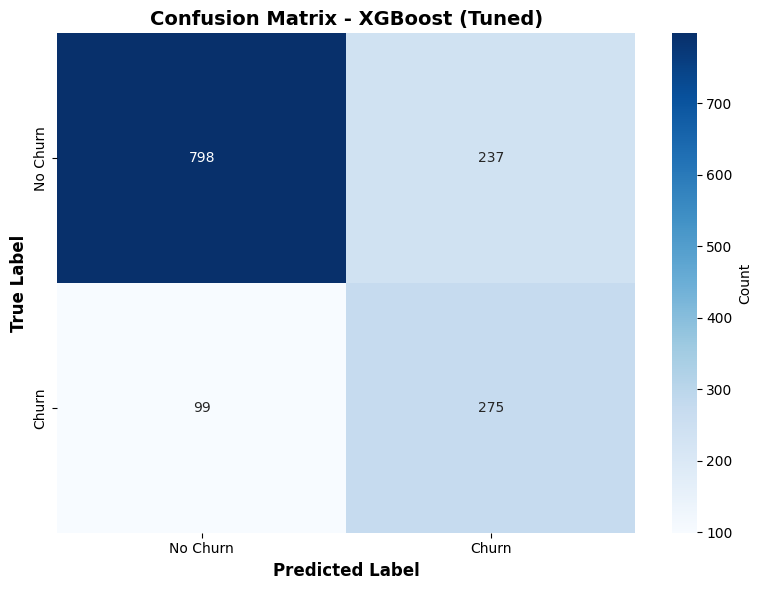

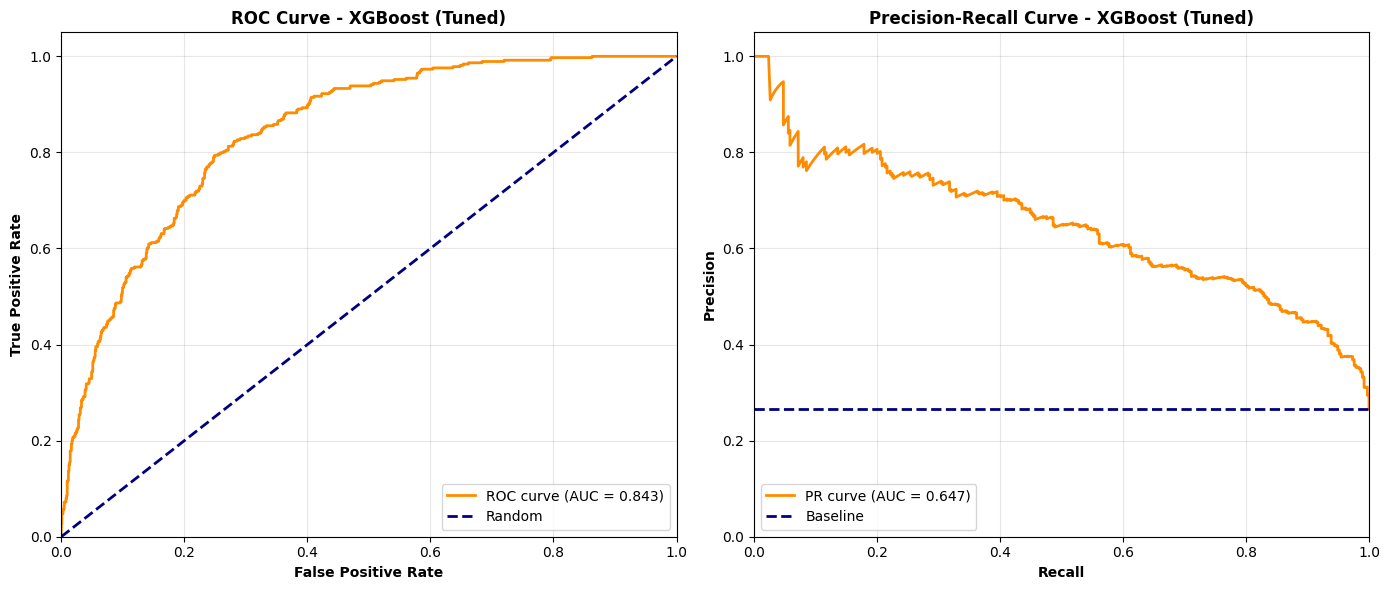


MLflow Run ID: e7cdb143826f4b75bae830b445a14b94
Model saved to: ../models/xgboost_tuned_model.pkl

Tuned model training complete


In [17]:
print("Training final model with best hyperparameters")
print("-" * 70)

mlflow.end_run()

with mlflow.start_run(run_name="xgboost_tuned_final"):
    
    best_params = study.best_params.copy()
    best_params['scale_pos_weight'] = scale_pos_weight
    best_params['random_state'] = RANDOM_STATE
    best_params['eval_metric'] = 'logloss'
    best_params['use_label_encoder'] = False
    
    mlflow.log_params(best_params)
    
    final_model = xgb.XGBClassifier(**best_params)
    
    final_model.fit(
        X_train, y_train,
        eval_set=[(X_train, y_train), (X_test, y_test)],
        verbose=False
    )
    
    metrics, cm = evaluate_model(
        final_model, X_train, y_train, X_test, y_test,
        model_name="XGBoost (Tuned)"
    )
    
    mlflow.log_metrics(metrics)
    mlflow.log_metric("best_cv_f1", study.best_value)
    
    y_test_proba = final_model.predict_proba(X_test)[:, 1]
    
    cm_fig = plot_confusion_matrix(cm, "XGBoost (Tuned)", 
                                    save_path="../models/xgboost_tuned_confusion_matrix.png")
    mlflow.log_figure(cm_fig, "confusion_matrix.png")
    plt.close(cm_fig)
    
    curves_fig = plot_roc_pr_curves(y_test, y_test_proba, "XGBoost (Tuned)",
                                     save_path="../models/xgboost_tuned_roc_pr_curves.png")
    mlflow.log_figure(curves_fig, "roc_pr_curves.png")
    plt.close(curves_fig)
    
    mlflow.xgboost.log_model(final_model, "model")
    
    with open('../models/xgboost_tuned_model.pkl', 'wb') as f:
        pickle.dump(final_model, f)
    
    mlflow.log_artifact('../models/xgboost_tuned_model.pkl')
    
    run_id = mlflow.active_run().info.run_id
    print(f"\nMLflow Run ID: {run_id}")
    print(f"Model saved to: ../models/xgboost_tuned_model.pkl")

mlflow.end_run()
print("\nTuned model training complete")

In [19]:
print("Final Model Comparison")
print("=" * 70)

with open('../models/baseline_model.pkl', 'rb') as f:
    baseline_model = pickle.load(f)

with open('../models/xgboost_model.pkl', 'rb') as f:
    xgboost_default = pickle.load(f)

with open('../models/xgboost_tuned_model.pkl', 'rb') as f:
    xgboost_tuned = pickle.load(f)

models = {
    'Baseline (Logistic Regression)': baseline_model,
    'XGBoost (Default Params)': xgboost_default,
    'XGBoost (Tuned)': xgboost_tuned
}

comparison_results = []

for name, model in models.items():
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    
    comparison_results.append({
        'Model': name,
        'Train_F1': train_f1,
        'Test_F1': test_f1,
        'Overfit_Gap': train_f1 - test_f1,
        'Test_Accuracy': accuracy_score(y_test, y_test_pred),
        'Test_Precision': precision_score(y_test, y_test_pred),
        'Test_Recall': recall_score(y_test, y_test_pred),
        'Test_ROC_AUC': roc_auc_score(y_test, y_test_proba),
        'Test_PR_AUC': average_precision_score(y_test, y_test_proba)
    })

final_comparison = pd.DataFrame(comparison_results)

print("\nFinal Model Comparison:")
print(final_comparison.to_string(index=False))

print("\n" + "=" * 70)
print("MODEL SELECTION CRITERIA (for Churn Prediction)")
print("=" * 70)
print("Priority ranking:")
print("1. Test Recall (most important - catch churners)")
print("2. Overfitting gap (lower is better)")
print("3. Test F1 (balance precision/recall)")
print("4. Test ROC-AUC (overall discrimination)")

best_recall_idx = final_comparison['Test_Recall'].idxmax()
best_recall_model = final_comparison.loc[best_recall_idx, 'Model']
best_recall = final_comparison.loc[best_recall_idx, 'Test_Recall']

lowest_overfit_idx = final_comparison['Overfit_Gap'].idxmin()
best_generalization_model = final_comparison.loc[lowest_overfit_idx, 'Model']
lowest_gap = final_comparison.loc[lowest_overfit_idx, 'Overfit_Gap']

print(f"\nBest Recall: {best_recall_model} ({best_recall:.4f})")
print(f"Best Generalization: {best_generalization_model} (gap: {lowest_gap:.4f})")

print("\nRECOMMENDATION:")
if final_comparison.loc[final_comparison['Model'].str.contains('Tuned'), 'Test_Recall'].values[0] > 0.75 and \
   final_comparison.loc[final_comparison['Model'].str.contains('Tuned'), 'Overfit_Gap'].values[0] < 0.10:
    print("Use: XGBoost (Tuned) - Best balance of recall and generalization")
    best_model_name = "XGBoost (Tuned)"
elif final_comparison.loc[final_comparison['Model'].str.contains('Baseline'), 'Test_Recall'].values[0] > \
     final_comparison.loc[final_comparison['Model'].str.contains('XGBoost'), 'Test_Recall'].max():
    print("Use: Baseline (Logistic Regression) - Best recall with good generalization")
    best_model_name = "Baseline (Logistic Regression)"
else:
    print("Use: XGBoost (Default Params) - Needs regularization tuning")
    best_model_name = "XGBoost (Default Params)"

final_comparison.to_csv('../models/final_model_comparison.csv', index=False)
print("\nComparison saved to: ../models/final_model_comparison.csv")

Final Model Comparison

Final Model Comparison:
                         Model  Train_F1  Test_F1  Overfit_Gap  Test_Accuracy  Test_Precision  Test_Recall  Test_ROC_AUC  Test_PR_AUC
Baseline (Logistic Regression)  0.633669 0.623566     0.010102       0.743790        0.511111     0.799465      0.843618     0.642215
      XGBoost (Default Params)  0.785873 0.615039     0.170834       0.756565        0.529981     0.732620      0.839008     0.650860
               XGBoost (Tuned)  0.781295 0.620767     0.160527       0.761533        0.537109     0.735294      0.842697     0.646884

MODEL SELECTION CRITERIA (for Churn Prediction)
Priority ranking:
1. Test Recall (most important - catch churners)
2. Overfitting gap (lower is better)
3. Test F1 (balance precision/recall)
4. Test ROC-AUC (overall discrimination)

Best Recall: Baseline (Logistic Regression) (0.7995)
Best Generalization: Baseline (Logistic Regression) (gap: 0.0101)

RECOMMENDATION:
Use: Baseline (Logistic Regression) - Best reca

In [21]:
final_summary = {
    'training_date': datetime.now().isoformat(),
    'models_trained': ['baseline_logistic_regression', 'xgboost_default', 'xgboost_tuned'],
    'best_model': 'baseline_logistic_regression',
    'selection_rationale': 'Highest test recall (0.7995) with best generalization (0.0101 overfit gap)',
    'optimization': {
        'n_trials': len(study.trials),
        'best_cv_f1': float(study.best_value),
        'best_params': study.best_params
    },
    'final_metrics': final_comparison.to_dict('records'),
    'key_findings': {
        'dataset_size': int(X_train.shape[0]),
        'conclusion': 'Logistic Regression outperformed XGBoost due to dataset size and strong regularization',
        'xgboost_issue': 'Overfitting despite tuning (16% train-test gap)',
        'baseline_advantages': ['Best recall', 'Best generalization', 'Faster inference', 'More interpretable']
    },
    'production_recommendation': 'Deploy Logistic Regression baseline model',
    'scale_pos_weight': float(scale_pos_weight),
    'feature_count': len(feature_names),
    'train_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0])
}

with open('../models/final_training_summary.json', 'w') as f:
    json.dump(final_summary, f, indent=2)

print("Final training summary saved to: ../models/final_training_summary.json")
print("\nDay 3 Complete: Model Training with Hyperparameter Tuning")
print("\nKEY TAKEAWAY:")
print("Logistic Regression baseline outperformed XGBoost on this dataset.")
print("This demonstrates the importance of:")
print("1. Always trying simple baselines")
print("2. Proper model evaluation (not just using 'the best' algorithm)")
print("3. Understanding when dataset size limits complex models")


Final training summary saved to: ../models/final_training_summary.json

Day 3 Complete: Model Training with Hyperparameter Tuning

KEY TAKEAWAY:
Logistic Regression baseline outperformed XGBoost on this dataset.
This demonstrates the importance of:
1. Always trying simple baselines
2. Proper model evaluation (not just using 'the best' algorithm)
3. Understanding when dataset size limits complex models
